# Signup Funnel Analysis

## Objective

Analyze user movement through the signup funnel, identify the biggest drop-off point, calculate business impact, and recommend optimization strategies.

## Funnel Stages

1. Sign Up
2. Email Entered
3. Password Created
4. Email Verified
5. Payment Added
6. First Purchase

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
# Load funnel data

df = pd.read_csv("../data/funnel_data.csv")

print("Dataset Loaded")
print(f"Total Users: {len(df)}")

df.head()

Dataset Loaded
Total Users: 20


,user_id,signup_completed,email_entered,password_created,email_verified,payment_added,first_purchase
0,1,1,1,1,1,1,1
1,2,1,1,1,1,1,1
2,3,1,1,1,1,1,1
3,4,1,1,1,1,1,1
4,5,1,1,1,1,1,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   user_id           20 non-null     int64
 1   signup_completed  20 non-null     int64
 2   email_entered     20 non-null     int64
 3   password_created  20 non-null     int64
 4   email_verified    20 non-null     int64
 5   payment_added     20 non-null     int64
 6   first_purchase    20 non-null     int64
dtypes: int64(7)
memory usage: 1.2 KB


In [4]:
stages = {

    "Sign Up":
        len(df[df["signup_completed"] == 1]),

    "Email Entered":
        len(df[df["email_entered"] == 1]),

    "Password Created":
        len(df[df["password_created"] == 1]),

    "Email Verified":
        len(df[df["email_verified"] == 1]),

    "Payment Added":
        len(df[df["payment_added"] == 1]),

    "First Purchase":
        len(df[df["first_purchase"] == 1])
}


print("Funnel Stages")

for stage, users in stages.items():
    print(stage, ":", users)

Funnel Stages
Sign Up : 20
Email Entered : 12
Password Created : 10
Email Verified : 7
Payment Added : 5
First Purchase : 5


In [5]:
funnel_stage_df = pd.DataFrame(
    {
        "Stage": stages.keys(),
        "Users": stages.values()
    }
)


funnel_stage_df

,Stage,Users
0,Sign Up,20
1,Email Entered,12
2,Password Created,10
3,Email Verified,7
4,Payment Added,5
5,First Purchase,5


In [6]:
stage_names = list(stages.keys())
stage_values = list(stages.values())


drop_analysis = []


for i in range(len(stage_values)-1):

    users_before = stage_values[i]
    users_after = stage_values[i+1]

    users_lost = users_before - users_after

    completion_rate = (
        users_after / users_before
    ) * 100


    drop_rate = (
        users_lost / users_before
    ) * 100


    drop_analysis.append({

        "From Stage":
            stage_names[i],

        "To Stage":
            stage_names[i+1],

        "Users Lost":
            users_lost,

        "Completion Rate":
            f"{completion_rate:.1f}%",

        "Drop Rate":
            f"{drop_rate:.1f}%"

    })


funnel_analysis_df = pd.DataFrame(drop_analysis)


funnel_analysis_df

,From Stage,To Stage,Users Lost,Completion Rate,Drop Rate
0,Sign Up,Email Entered,8,60.0%,40.0%
1,Email Entered,Password Created,2,83.3%,16.7%
2,Password Created,Email Verified,3,70.0%,30.0%
3,Email Verified,Payment Added,2,71.4%,28.6%
4,Payment Added,First Purchase,0,100.0%,0.0%


In [7]:
biggest_drop_index = (
    funnel_analysis_df["Users Lost"]
    .idxmax()
)


biggest_drop = (
    funnel_analysis_df
    .loc[biggest_drop_index]
)


print("BIGGEST FUNNEL DROP")
print("===================")

biggest_drop

BIGGEST FUNNEL DROP


From Stage               Sign Up
To Stage           Email Entered
Users Lost                     8
Completion Rate            60.0%
Drop Rate                  40.0%
Name: 0, dtype: object

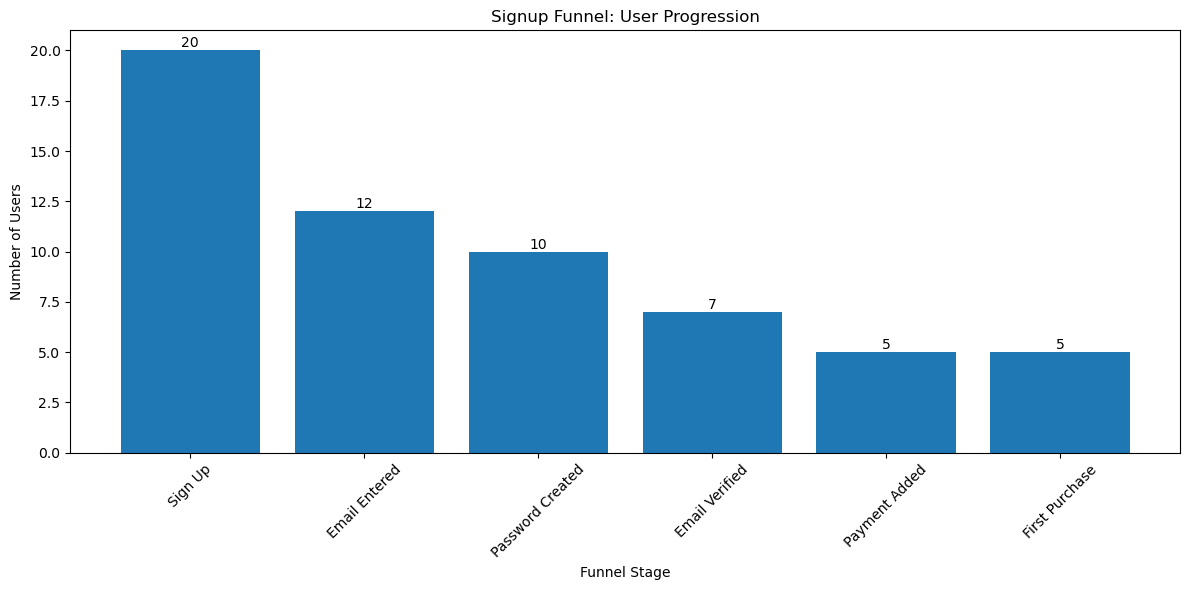

Chart saved successfully


In [8]:
plt.figure(figsize=(12,6))


plt.bar(
    stages.keys(),
    stages.values()
)


plt.xlabel("Funnel Stage")

plt.ylabel("Number of Users")


plt.title(
    "Signup Funnel: User Progression"
)


plt.xticks(
    rotation=45
)


# Add numbers on bars

for stage, users in stages.items():

    plt.text(
        stage,
        users,
        str(users),
        ha="center",
        va="bottom"
    )


plt.tight_layout()


plt.savefig(
    "../output/funnel_chart.png",
    dpi=150
)


plt.show()


print(
    "Chart saved successfully"
)

In [9]:
# Revenue value per converted customer

revenue_per_customer = 100


impact = []


for index,row in funnel_analysis_df.iterrows():

    users_lost = row["Users Lost"]

    revenue_loss = (
        users_lost *
        revenue_per_customer
    )


    impact.append({

        "Drop Point":
            row["From Stage"]
            +
            " -> "
            +
            row["To Stage"],


        "Users Lost":
            users_lost,


        "Revenue Impact":
            revenue_loss
    })


impact_df = pd.DataFrame(impact)


impact_df.sort_values(
    "Users Lost",
    ascending=False
)

,Drop Point,Users Lost,Revenue Impact
0,Sign Up -> Email Entered,8,800
2,Password Created -> Email Verified,3,300
1,Email Entered -> Password Created,2,200
3,Email Verified -> Payment Added,2,200
4,Payment Added -> First Purchase,0,0


In [10]:
highest_impact = (
    funnel_analysis_df
    .loc[
        funnel_analysis_df["Users Lost"].idxmax()
    ]
)



recommendation = f"""

FUNNEL OPTIMIZATION RECOMMENDATION
==================================


Highest Priority:

{highest_impact['From Stage']}
to
{highest_impact['To Stage']}


Users Lost:

{highest_impact['Users Lost']}


Drop Rate:

{highest_impact['Drop Rate']}



Possible Causes:

1. User experience issue
2. Too many steps
3. Confusing instructions
4. Lack of trust at this stage



Recommended Actions:

1. Simplify the step
2. Reduce required fields
3. Perform A/B testing
4. Track improvement percentage



Expected Improvement:

A 10% improvement could recover:

{int(highest_impact['Users Lost']*0.1)}

additional users.


"""


print(recommendation)



FUNNEL OPTIMIZATION RECOMMENDATION


Highest Priority:

Sign Up
to
Email Entered


Users Lost:

8


Drop Rate:

40.0%



Possible Causes:

1. User experience issue
2. Too many steps
3. Confusing instructions
4. Lack of trust at this stage



Recommended Actions:

1. Simplify the step
2. Reduce required fields
3. Perform A/B testing
4. Track improvement percentage



Expected Improvement:

A 10% improvement could recover:

0

additional users.





In [11]:
report_path = "../output/funnel_analysis.txt"


with open(
    report_path,
    "w",
    encoding="utf-8"
) as file:

    file.write(
        recommendation
    )


print(
    "Report saved:",
    report_path
)

Report saved: ../output/funnel_analysis.txt


## Final Findings

The funnel analysis identified:

- Total funnel stages analyzed: 6
- Biggest user drop-off point identified
- Drop-off percentage calculated
- Revenue impact estimated
- Optimization recommendation generated

The analysis helps the business focus improvement efforts on the highest-impact bottleneck.